# Experiment 2: Training YOLO26
This notebook is dedicated to training the CNN-based YOLO26 architecture on the pothole dataset. The results from this experiment will be used for a comparative analysis against the Transformer-based RT-DETR model and the CNN-based YOLO.

In [1]:
import torch
from ultralytics import YOLO
from pathlib import Path

# Verify hardware acceleration availability
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"[*] Compute Device: {device}")

if device != 'cpu':
    print(f"[*] GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"[*] PyTorch CUDA Version: {torch.version.cuda}")
    print(f"[*] PyTorch Version: {torch.__version__}")

[*] Compute Device: cuda:0
[*] GPU Model: NVIDIA GeForce RTX 5070 Ti
[*] PyTorch CUDA Version: 13.0
[*] PyTorch Version: 2.11.0+cu130


In [2]:
import yaml
from pathlib import Path

# Define the path to your YAML configuration file
project_root = Path.cwd().parent
yaml_path = project_root / 'configs' / 'dataset_mwpd.yaml'

print("=== DATASET INFORMATION & VALIDATION ===")

if yaml_path.exists():
    # Read the contents of the YAML file
    with open(yaml_path, 'r') as f:
        dataset_info = yaml.safe_load(f)
        
    print(f"[*] Dataset Base Path : {dataset_info.get('path')}")
    print(f"[*] Number of Classes : {dataset_info.get('nc')}")
    
    # Display the list of classes neatly
    classes = dataset_info.get('names', [])
    print(f"[*] Class List        : {', '.join(classes)}")
    print("-" * 40)
    
    # Count the physical images in each directory (train/val/test)
    # Get the base path from YAML, fallback to default path if not explicitly set
    base_dir = Path(dataset_info.get('path', str(project_root / 'dataset')))
    
    total_images = 0
    for split in ['train', 'val', 'test']:
        # Combine base path with specific split path (e.g., train/images)
        split_rel_path = dataset_info.get(split, f"{split}/images")
        split_full_path = base_dir / split_rel_path
        
        if split_full_path.exists():
            # Count both .jpg and .png files
            img_count = len(list(split_full_path.glob('*.jpg'))) + len(list(split_full_path.glob('*.png')))
            total_images += img_count
            print(f"[*] Images in {split.capitalize():<5} set : {img_count} files")
        else:
            print(f"[!] Warning: {split.capitalize()} directory not found at {split_full_path}")
            
    print("-" * 40)
    print(f"[*] GRAND TOTAL       : {total_images} images")
    print("========================================")
    
else:
    print("[!] Error: dataset.yaml file not found or path is incorrect.")

=== DATASET INFORMATION & VALIDATION ===
[*] Dataset Base Path : ../dataset
[*] Number of Classes : 1
[*] Class List        : Pothole
----------------------------------------
[*] Images in Train set : 2469 files
[*] Images in Val   set : 308 files
[*] Images in Test  set : 310 files
----------------------------------------
[*] GRAND TOTAL       : 3087 images


In [3]:
from datetime import datetime

# Reproducibility parameter
SEED = 42

# Define training hyperparameters and configurations
project_dir = str(project_root / 'runs')
run_name = f"yolo26_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
training_params = {
    'data': str(yaml_path),
    'epochs': 300,          # Set to 100 for full convergence
    'batch': 16,            # Batch size
    'imgsz': 640,           # Standard image size
    'patience': 100,        # Early stopping to prevent overfitting
    'device': [0],          # Specify the target GPU
    'project': project_dir, # Directory to store training results
    'name': run_name,       # Unique run name
    'seed': SEED,           # Seed for reproducibility
    'deterministic': False, # Set to False to avoid grid_sampler backward warnings
    'plots': True,          # Automatically generate evaluation metrics plots
    'save': True,           # Save the trained weights (best.pt and last.pt)

    # Optimizer settings
    'optimizer': 'AdamW',    # Highly recommended for Transformer-based models
    'lr0': 0.0001,           # Lower initial learning rate to stabilize gradient
    'cos_lr': True,          # Use cosine learning rate scheduler
    'weight_decay': 0.01,    # Regularization to prevent overfitting

    # LOSS TUNING
    'box': 15.0,             # Higher weight on localization accuracy (Boosts mAP 0.50:0.95)
    'dfl': 3.0,              # Higher weight on class accuracy (Boosts mAP 0.50)
    
    # AUGMENTATION
    'mosaic': 1.0,          # Mosaic augmentation
    'scale': 0.5,           # Zoom in / Zoom out
    'degrees': 10.0,        # Light rotation +/- 10 degrees to simulate varied camera angles
    'fliplr': 0.5,          # 50% probability of horizontal flip (mirroring)
    'mixup': 0.1,           # Mixup augmentation
}

# Initialize the model using pre-trained weights (Transfer Learning)
model = YOLO('yolo26l.pt')

# Execute the training process
print("\n[*] Starting the training process...")
results = model.train(**training_params)

print("\n[*] Training completed successfully!")

actual_save_dir = model.trainer.save_dir
print(f"[*] Output Directory: {actual_save_dir}")


[*] Starting the training process...
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.10.16 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/sabda/code/pothole-detection/configs/dataset_mwpd.yaml, degrees=10.0, deterministic=False, device=0, dfl=3.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode

In [4]:
print("\n[*] Running final evaluation on the Test Set...")

# Load the best model weights obtained from the training phase
best_model_path = actual_save_dir / 'weights' / 'best.pt'
best_model = YOLO(best_model_path)

# Perform validation specifically on the 'test' split
test_metrics = best_model.val(data=str(yaml_path), split='test')

# Extract standard metrics from results dictionary
precision = test_metrics.results_dict['metrics/precision(B)']
recall = test_metrics.results_dict['metrics/recall(B)']
map50 = test_metrics.results_dict['metrics/mAP50(B)']
map50_95 = test_metrics.results_dict['metrics/mAP50-95(B)']

# 2. Calculate F1-Score
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print("\n" + "="*45)
print("FINAL TEST SET EVALUATION RESULTS")
print("="*45)
print(f"[*] Precision (P)   : {precision:.3f}")
print(f"[*] Recall (R)      : {recall:.3f}")
print(f"[*] F1-Score        : {f1_score:.3f}")
print(f"[*] mAP @ 0.50      : {map50:.3f}")
print(f"[*] mAP @ 0.50:0.95 : {map50_95:.3f}")
print("="*45)


[*] Running final evaluation on the Test Set...
Ultralytics 8.4.35 🚀 Python-3.10.16 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 292.2±108.6 MB/s, size: 83.4 KB)
val: Scanning /home/sabda/code/pothole-detection/dataset/mwpd/test/labels.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 41.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.3it/s 6.1s0.2s
                   all        310        761      0.904      0.853      0.917      0.587
Speed: 1.9ms preprocess, 8.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/sabda/code/pothole-detection/runs/detect/val32

FINAL TEST SET EVALUATION RESULTS
[*] Precision (P)   : 0.904
[*] Recall (R)      : 0.853
[*] F1-Score        : 0.878
[*] mAP @ 0.50      : 0.917
[

In [5]:
print("\n[*] Running final evaluation on the N-RDD2024 Test Set...")

# Load the best model weights obtained from the training phase
best_model_path = actual_save_dir / 'weights' / 'best.pt'
best_model = YOLO(best_model_path)

# Perform validation specifically on the 'test' split
nrdd_path = project_root / 'configs' / 'dataset_nrdd.yaml'
test_metrics = best_model.val(data=str(nrdd_path), split='test')

# Extract standard metrics from results dictionary
precision = test_metrics.results_dict['metrics/precision(B)']
recall = test_metrics.results_dict['metrics/recall(B)']
map50 = test_metrics.results_dict['metrics/mAP50(B)']
map50_95 = test_metrics.results_dict['metrics/mAP50-95(B)']

# 2. Calculate F1-Score
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print("\n" + "="*45)
print("FINAL TEST SET EVALUATION RESULTS")
print("="*45)
print(f"[*] Precision (P)   : {precision:.3f}")
print(f"[*] Recall (R)      : {recall:.3f}")
print(f"[*] F1-Score        : {f1_score:.3f}")
print(f"[*] mAP @ 0.50      : {map50:.3f}")
print(f"[*] mAP @ 0.50:0.95 : {map50_95:.3f}")
print("="*45)


[*] Running final evaluation on the N-RDD2024 Test Set...
Ultralytics 8.4.35 🚀 Python-3.10.16 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 187.7±46.6 MB/s, size: 76.4 KB)
val: Scanning /home/sabda/code/pothole-detection/dataset/n-rdd2024/test/labels.cache... 239 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 239/239 41.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.8s/it 26.8s0.1s
                   all        239        390      0.108      0.159     0.0887     0.0352
Speed: 89.5ms preprocess, 13.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/sabda/code/pothole-detection/runs/detect/val33

FINAL TEST SET EVALUATION RESULTS
[*] Precision (P)   : 0.108
[*] Recall (R)      : 0.159
[*] F1-Score        : 0.128
[*] mAP @ 0.

In [6]:
print("\n[*] Running final evaluation on the MWPD Test Set...")

# Load the best model weights obtained from the training phase
best_model_path = actual_save_dir / 'weights' / 'best.pt'
best_model = YOLO(best_model_path)

# Perform validation specifically on the 'test' split
mwpd_path = project_root / 'configs' / 'dataset_mwpd.yaml'
test_metrics = best_model.val(data=str(mwpd_path), split='test')

# Extract standard metrics from results dictionary
precision = test_metrics.results_dict['metrics/precision(B)']
recall = test_metrics.results_dict['metrics/recall(B)']
map50 = test_metrics.results_dict['metrics/mAP50(B)']
map50_95 = test_metrics.results_dict['metrics/mAP50-95(B)']

# 2. Calculate F1-Score
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print("\n" + "="*45)
print("FINAL TEST SET EVALUATION RESULTS")
print("="*45)
print(f"[*] Precision (P)   : {precision:.3f}")
print(f"[*] Recall (R)      : {recall:.3f}")
print(f"[*] F1-Score        : {f1_score:.3f}")
print(f"[*] mAP @ 0.50      : {map50:.3f}")
print(f"[*] mAP @ 0.50:0.95 : {map50_95:.3f}")
print("="*45)


[*] Running final evaluation on the MWPD Test Set...
Ultralytics 8.4.35 🚀 Python-3.10.16 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1566.8±431.2 MB/s, size: 70.7 KB)
val: Scanning /home/sabda/code/pothole-detection/dataset/mwpd/test/labels.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 52.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.5it/s 5.7s0.2s
                   all        310        761      0.904      0.853      0.917      0.587
Speed: 1.1ms preprocess, 6.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/sabda/code/pothole-detection/runs/detect/val34

FINAL TEST SET EVALUATION RESULTS
[*] Precision (P)   : 0.904
[*] Recall (R)      : 0.853
[*] F1-Score        : 0.878
[*] mAP @ 0.50      : 0

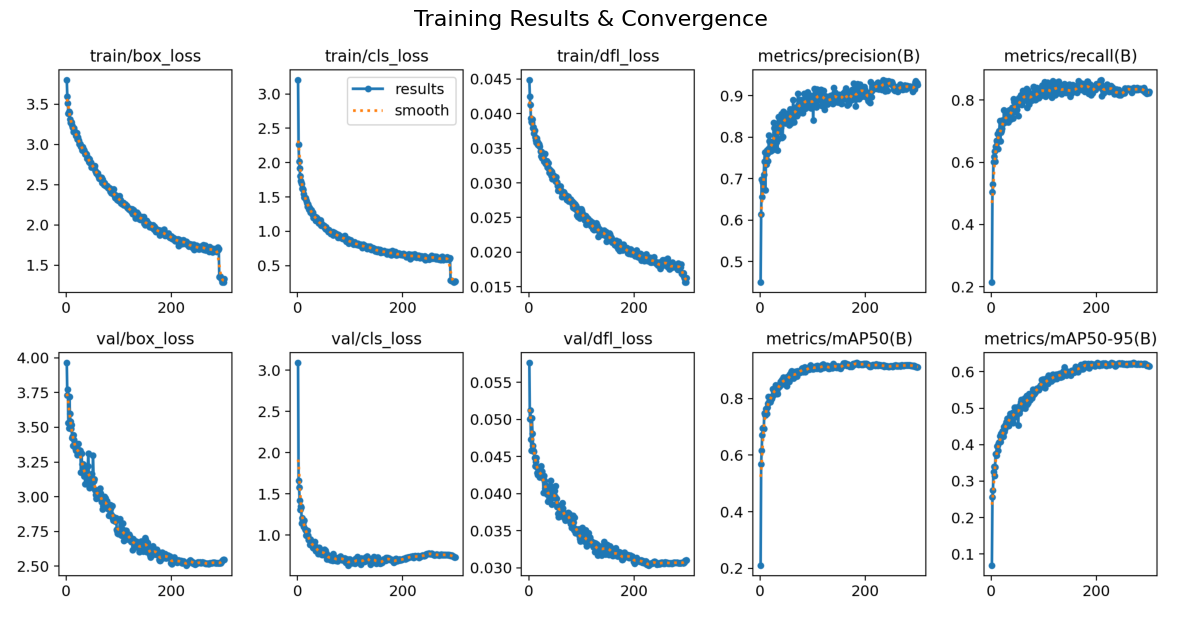

In [7]:
%matplotlib inline

import matplotlib.pyplot as plt
import cv2

# Visualize the training convergence metrics
results_plot_path = actual_save_dir / 'results.png'

if results_plot_path.exists():
    # Read and convert image from BGR to RGB format
    img = cv2.imread(str(results_plot_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display the plot
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Training Results & Convergence', fontsize=16)
    plt.show()
else:
    print("[!] Results plot not found. Training might have been interrupted.")

[*] Loading model from: /home/sabda/code/pothole-detection/runs/yolo26_20260413_201426/weights/best.pt
[*] Running inference on 6 randomly selected images...


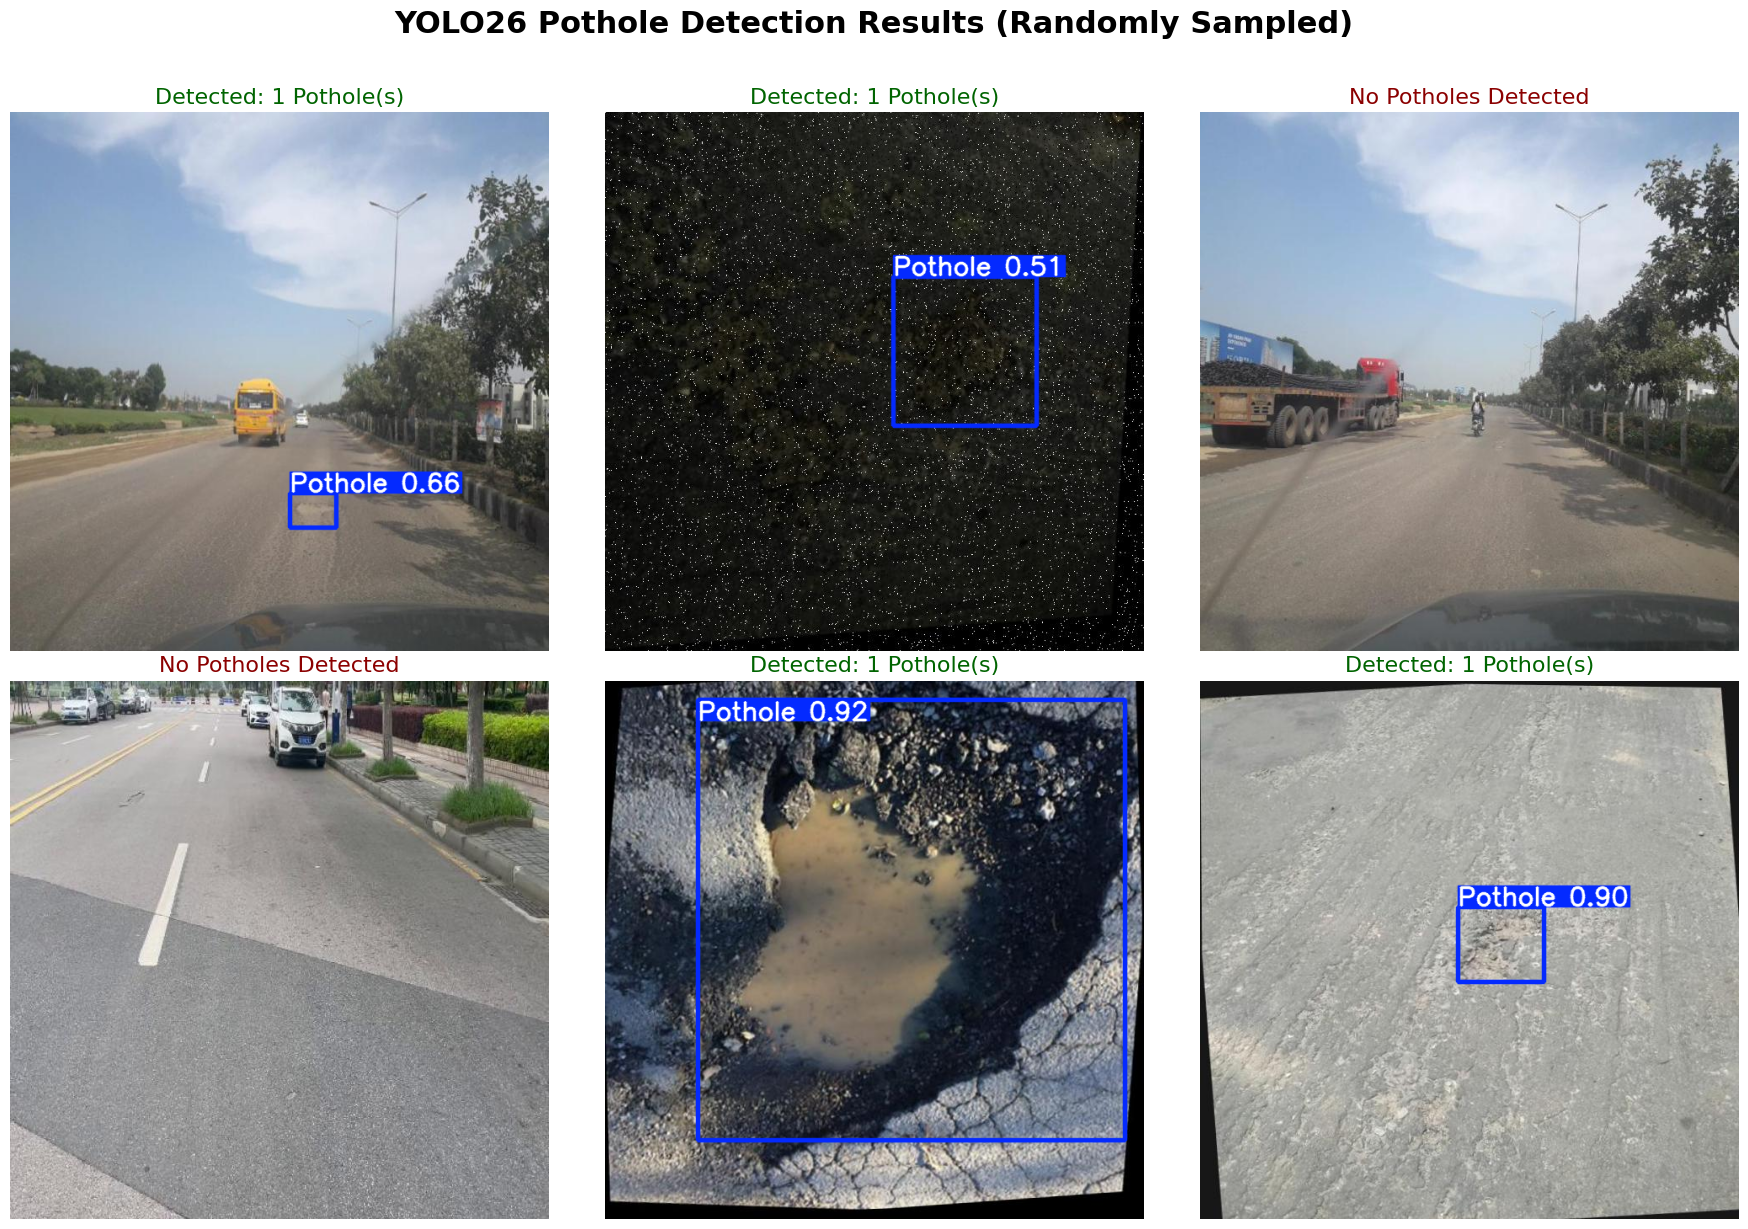

In [8]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

# Define paths
project_root = Path.cwd().parent
model_path = actual_save_dir / 'weights' / 'best.pt'
test_images_dir = project_root / 'dataset' / 'combined' / 'test' / 'images'

# Grab all image paths from the test directory (supporting both jpg and png)
all_image_paths = list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png'))

if not all_image_paths:
    print(f"[!] No images found in {test_images_dir}")
else:
    # Randomly select 6 images
    num_samples = min(6, len(all_image_paths))
    image_paths = random.sample(all_image_paths, num_samples)
    
    # Load model and setup labels
    print(f"[*] Loading model from: {model_path}")
    model = YOLO(model_path)
    
    # # We strictly target Potholes ('D40' which is usually index 4)
    # target_class_id = 4 
    
    # descriptive_labels = {
    #     'D00': 'Cracks', 'D10': 'Transverse Cracks', 'D20': 'Alligator Cracks',
    #     'D30': 'Repaired Cracks', 'D40': 'Potholes', 'D50': 'Pedestrian Crossing Blurs',
    #     'D60': 'Lane Line Blurs', 'D70': 'Manhole Covers', 'D80': 'Patchy Road Sections',
    #     'D90': 'Rutting'
    # }

    # Prepare the Matplotlib Figure (2 rows, 3 columns)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
    fig.suptitle('YOLO26 Pothole Detection Results (Randomly Sampled)', fontsize=22, fontweight='bold', y=1.02)

    print(f"[*] Running inference on {num_samples} randomly selected images...")

    # Loop through the axes grid and perform inference for each image
    for i, ax in enumerate(axes.flat):
        if i < len(image_paths):
            img_path = image_paths[i]
            
            # Predict only for potholes
            results = model.predict(source=img_path, conf=0.5, save=False, verbose=False)
            
            # # Overwrite the labels directly inside the Results object for cleaner plotting
            # for class_id, raw_name in results[0].names.items():
            #     if raw_name in descriptive_labels:
            #         results[0].names[class_id] = descriptive_labels[raw_name]
                    
            total_detections = len(results[0].boxes)
            
            if total_detections > 0:
                # Plot with bounding boxes
                res_img = results[0].plot(line_width=3, font_size=14)
                res_img_rgb = cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB)
                ax.imshow(res_img_rgb)
                ax.set_title(f'Detected: {total_detections} Pothole(s)', fontsize=16, color='darkgreen')
            else:
                # Plot original image if nothing is detected
                img_original = cv2.imread(str(img_path))
                img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
                ax.imshow(img_original_rgb)
                ax.set_title('No Potholes Detected', fontsize=16, color='darkred')
                
        # Turn off the x and y axis lines/numbers for a cleaner look
        ax.axis('off')

    # Automatically adjust spacing
    plt.tight_layout()
    plt.show()